--- Preview of Data ---
                      backdrop_path  \
0  /wdwcOBMkt3zmPQuEMxB3FUtMio2.jpg   
1  /8lBViysvNJBPkl6zG1LVAaW3qhj.jpg   
2  /w1oD1MzHjnBJc5snKupIQaSBLIh.jpg   
3  /85PMh0cKywekAJYDnRXfezYAmEc.jpg   
4  /tS3ByIQR6V61DaWhEIFbLSuLK5Q.jpg   

                               belongs_to_collection     budget  \
0  {'id': 131295, 'name': 'Captain America Collec...  250000000   
1  {'id': 645, 'name': 'James Bond Collection', '...  245000000   
2  {'id': 556, 'name': 'Spider-Man Collection', '...  258000000   
3                                                NaN  209000000   
4                                                NaN  200000000   

                                              genres  \
0  [{'id': 12, 'name': 'Adventure'}, {'id': 28, '...   
1  [{'id': 28, 'name': 'Action'}, {'id': 12, 'nam...   
2  [{'id': 28, 'name': 'Action'}, {'id': 12, 'nam...   
3  [{'id': 53, 'name': 'Thriller'}, {'id': 28, 'n...   
4  [{'id': 12, 'name': 'Adventure'}, {'id': 28, '...   

 

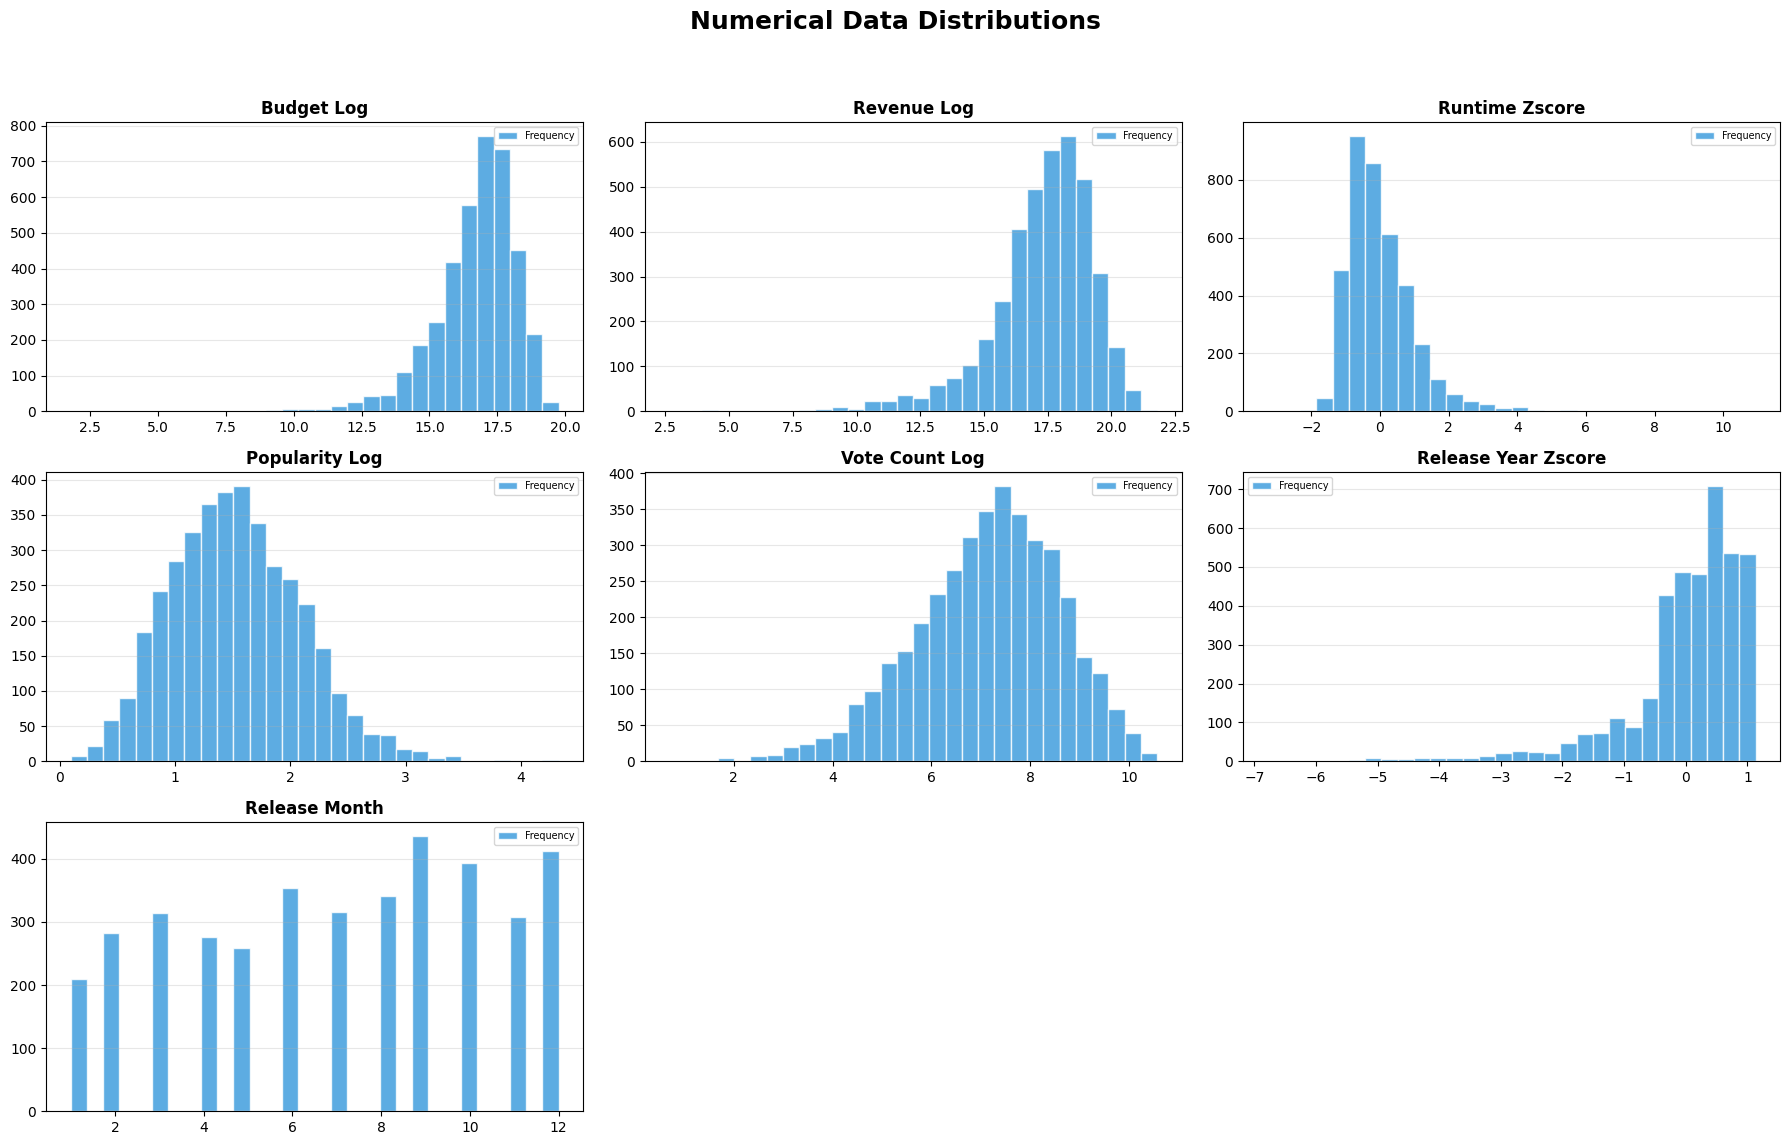

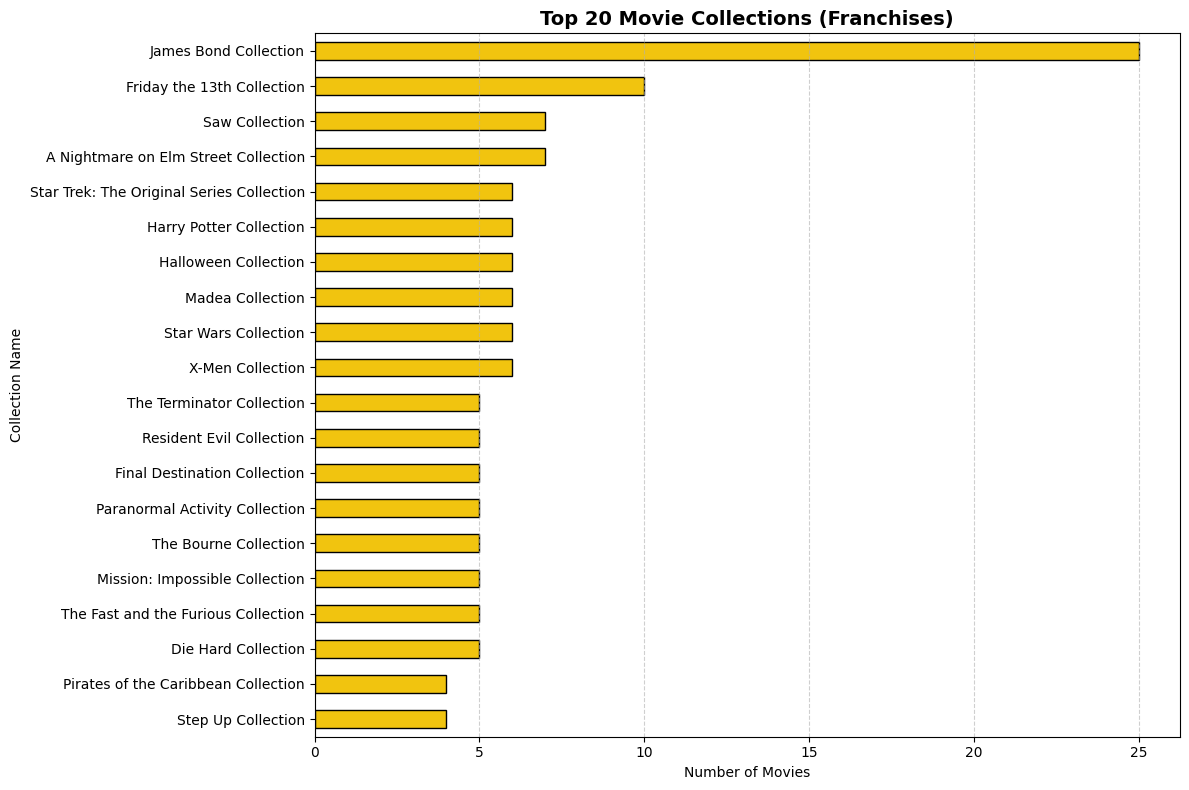

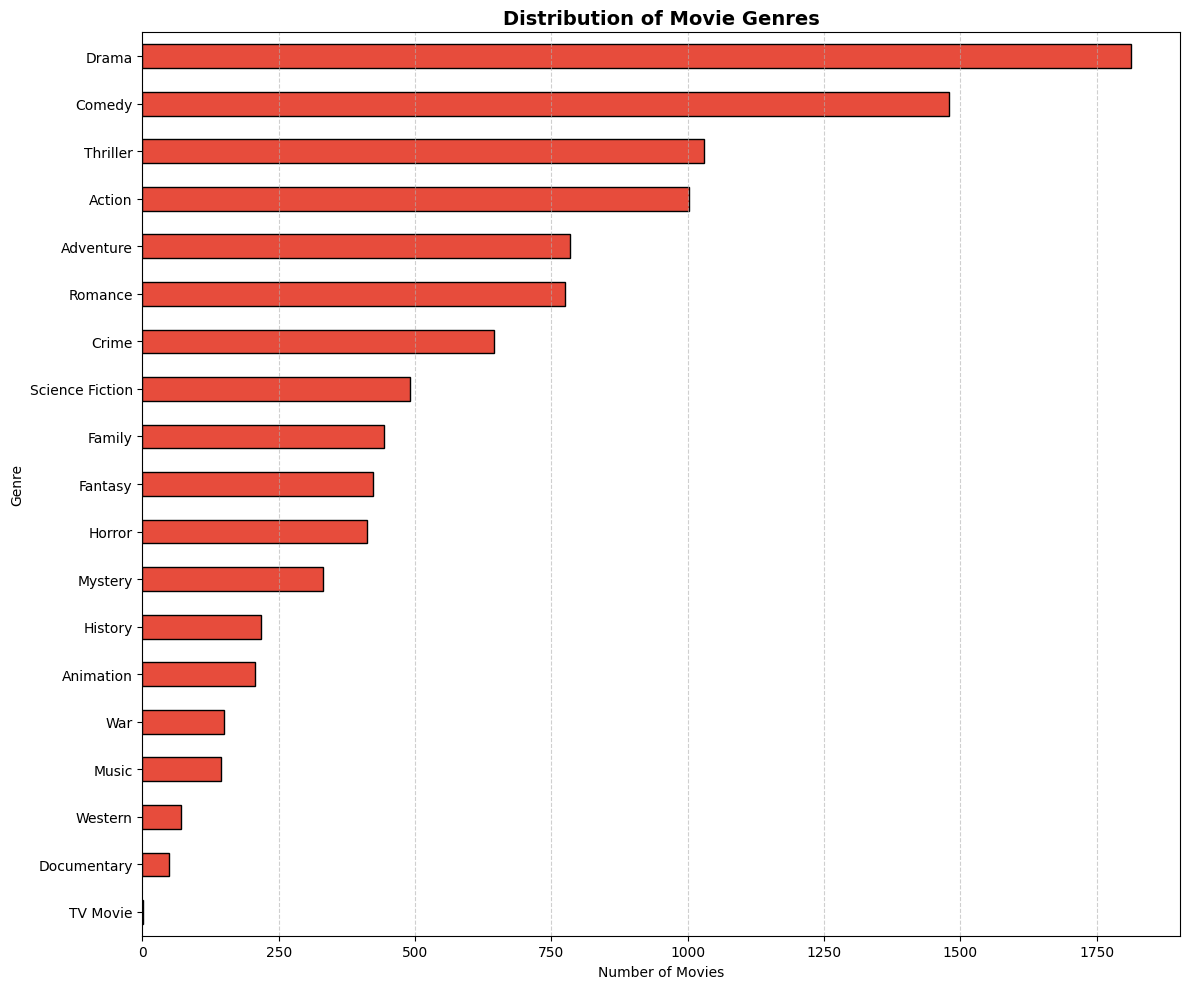

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the cleaned data
df = pd.read_csv("cleaned_tmdb_data.csv")

num_cols = ['budget_log', 'revenue_log', 'runtime_zscore', 
            'popularity_log', 'vote_count_log', 'release_year_zscore', 'release_month']

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 12))
fig.suptitle('Numerical Data Distributions', fontsize=18, fontweight='bold', y=0.98)

axes = axes.flatten()

for i, col in enumerate(num_cols):
    data = df[col].dropna()
    # Added 'label' so the legend has something to show
    axes[i].hist(data, bins=30, color='#3498db', edgecolor='white', alpha=0.8, label='Frequency')
    
    axes[i].set_title(f'{col.replace("_", " ").title()}', fontsize=12, fontweight='bold')
    axes[i].legend(fontsize='x-small') 
    axes[i].grid(axis='y', alpha=0.3)

# Hide any empty subplots in the 3x3 grid
for j in range(len(num_cols), len(axes)):
    axes[j].axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('numerical_distributions.png')

# 2. Top 20 Movie Collections (Horizontal Bar)
plt.figure(figsize=(12, 8))
# Filter out 'Standalone' to focus on actual franchises
collection_counts = df[df['collection'] != 'Standalone']['collection'].value_counts().head(20)

collection_counts.sort_values().plot(kind='barh', color='#f1c40f', edgecolor='black')
plt.title('Top 20 Movie Collections (Franchises)', fontsize=14, fontweight='bold')
plt.xlabel('Number of Movies')
plt.ylabel('Collection Name')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('top_collections.png')

# 3. Genre Distribution (Horizontal Bar)
plt.figure(figsize=(12, 10))
# Explode the pipe-separated genres to count individual genre occurrences
genre_counts = df['genres_cleaned'].str.split('|').explode().value_counts()
genre_counts.sort_values().plot(kind='barh', color='#e74c3c', edgecolor='black')

plt.title('Distribution of Movie Genres', fontsize=14, fontweight='bold')
plt.xlabel('Number of Movies')
plt.ylabel('Genre')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('genre_distribution.png')

print("--- Preview of Data ---")
print(df.head())

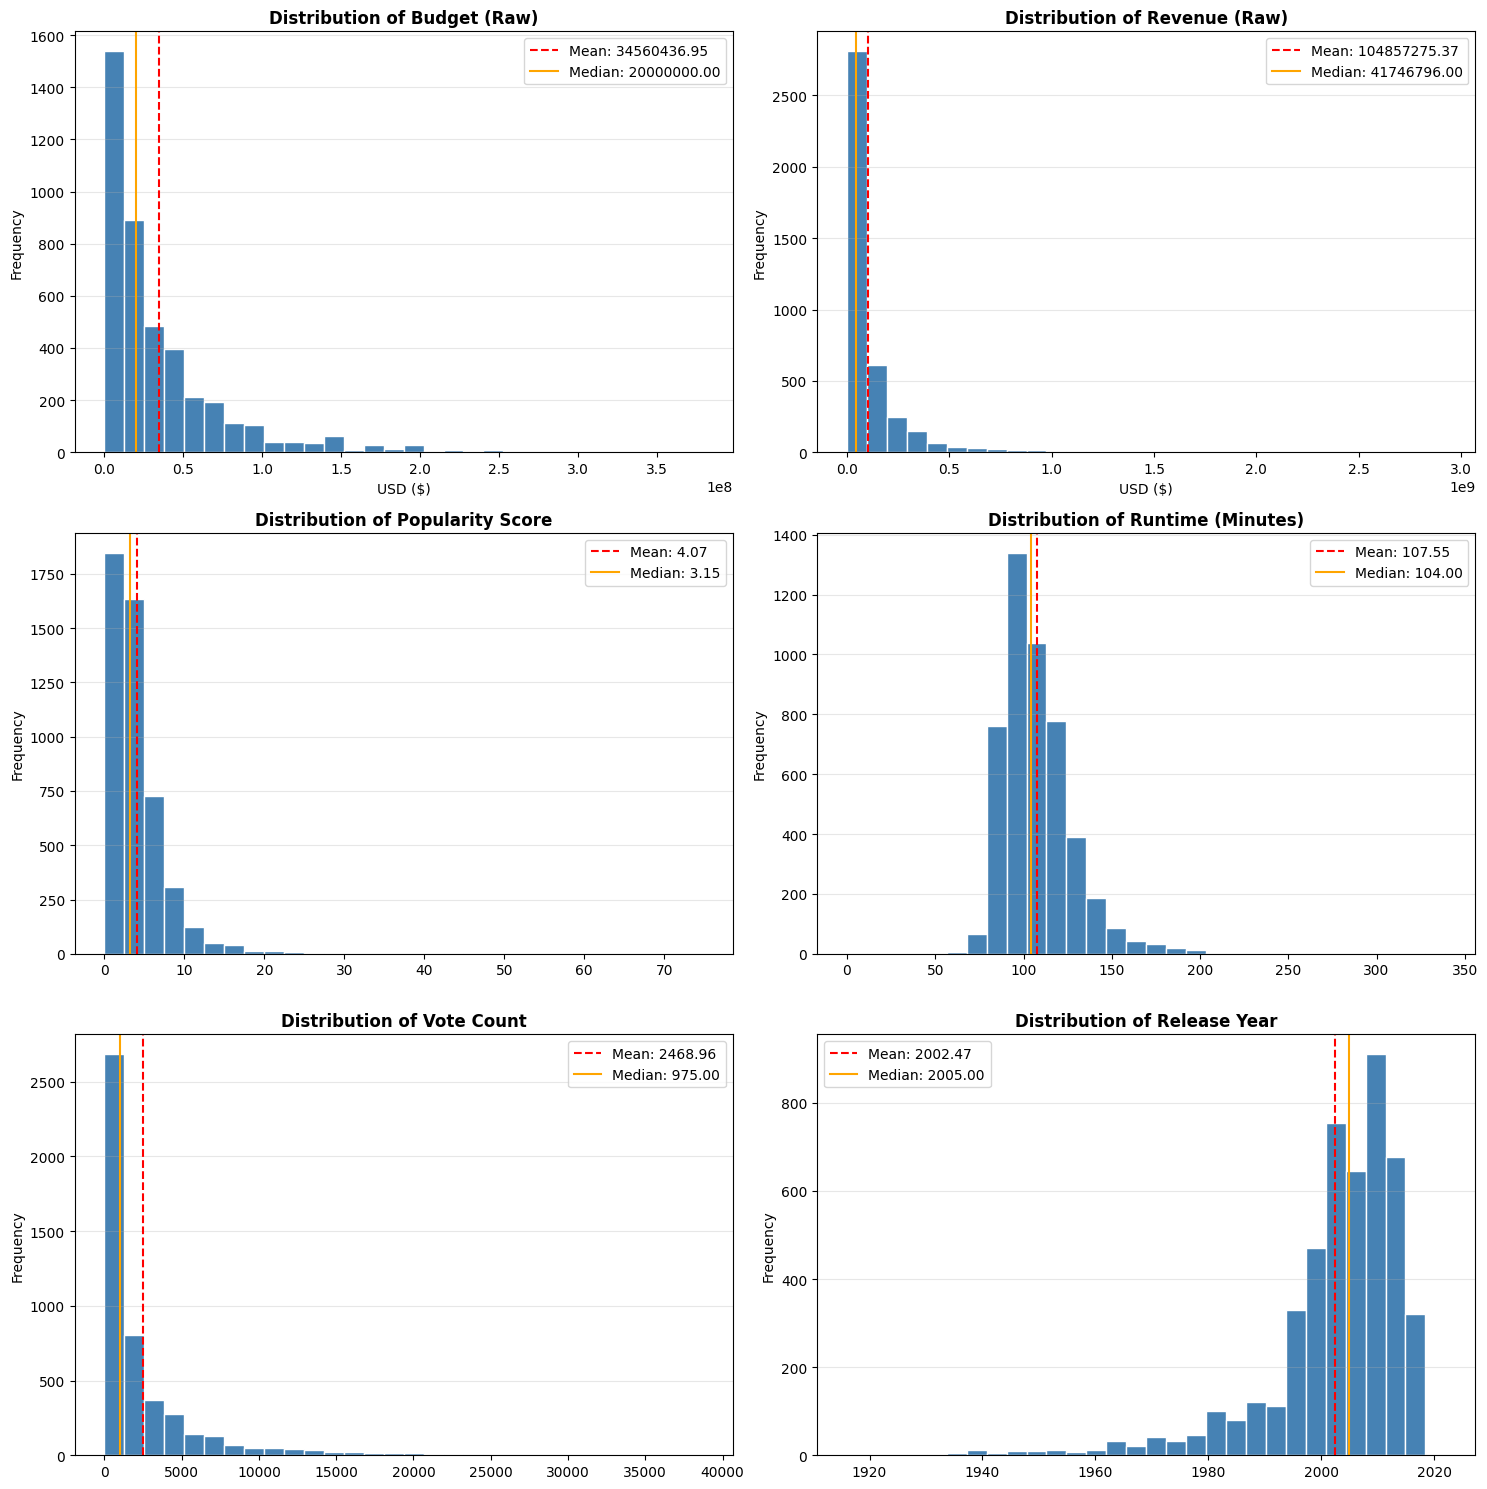

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the data
df = pd.read_csv('tmdb_full_export.csv')

# Define columns and display titles
cols = {
    'budget': 'Budget (Raw)',
    'revenue': 'Revenue (Raw)',
    'popularity': 'Popularity Score',
    'runtime': 'Runtime (Minutes)',
    'vote_count': 'Vote Count',
    'release_date': 'Release Year'
}

fig, axes = plt.subplots(3, 2, figsize=(15, 15))
axes = axes.flatten()

for i, (col, title) in enumerate(cols.items()):
    # 1. Pre-processing & Filtering
    if col in ['budget', 'revenue']:
        # Filter out 0s for financial data to see the distribution of actual values
        data_to_plot = df[df[col] > 0][col].dropna()
        axes[i].set_xlabel('USD ($)')
    elif col == "release_date":
        # Extract year and convert to numeric for the histogram
        years = df["release_date"].str.split("-").str[0]
        data_to_plot = pd.to_numeric(years, errors='coerce').dropna()
    else:
        # Standard numeric columns (popularity, runtime, vote_count)
        data_to_plot = df[col].dropna()
    
    # 2. Plotting Histogram
    # We use 30-50 bins for continuous data
    axes[i].hist(data_to_plot, bins=30, color='steelblue', edgecolor='white')
    
    # 3. Adding Median and Mean lines
    if not data_to_plot.empty:
        m_mean = data_to_plot.mean()
        m_median = data_to_plot.median()
        axes[i].axvline(m_mean, color='red', linestyle='--', label=f'Mean: {m_mean:.2f}')
        axes[i].axvline(m_median, color='orange', linestyle='-', label=f'Median: {m_median:.2f}')
        
    axes[i].set_title(f'Distribution of {title}', fontweight='bold')
    axes[i].set_ylabel('Frequency')
    axes[i].legend()
    axes[i].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()



In [18]:
constant_cols = [col for col in df.columns if df[col].nunique() <= 1]
print(f"Constant Columns: {constant_cols}")

Constant Columns: ['adult', 'status']


In [19]:
mismatches = df[df['title'].str.lower() != df['original_title'].str.lower()]
print(mismatches[['title','original_title']])

                             title  \
84                   Shin Godzilla   
221   Asterix at the Olympic Games   
304             The Flowers of War   
310              The Fifth Element   
461                      Evolution   
...                            ...   
4679               Paris Je T'aime   
4691                Quest for Fire   
4698                Shaolin Soccer   
4726        Kabhi Alvida Naa Kehna   
4738   Outlaws - For Greater Glory   

                                      original_title  
84                                            シン・ゴジラ  
221                      Astérix aux Jeux olympiques  
304                                            金陵十三釵  
310                             Le Cinquième Élément  
461                                        Évolution  
...                                              ...  
4679                                Paris, je t'aime  
4691                                La Guerre du feu  
4698                                            

In [ ]:
df[df.duplicated()]

,adult,backdrop_path,belongs_to_collection,budget,genres,homepage,id,imdb_id,origin_country,original_language,...,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count,translations
